# kNNとRandom Forestによる糖尿病データのクラス分類

`diabetes.csv` を使い、`Outcome` を目的変数としてクラス分類モデルを作成する。

このNotebookでは、kNN と Random Forest について、デフォルト設定の結果とハイパーパラメータチューニング後の結果を Hold-Out 検証で比較する。

【Python セミナー 第5回】  
前回までと同じように、CSVを読み込み、説明変数と目的変数に分け、トレーニングセットとテストセットに分割してからモデルを学習する。

今回は回帰ではなく分類なので、評価指標として Accuracy, Precision, Recall, F1, ROC AUC を使う。

In [1]:
# 必要なライブラリを読み込む。
# pandas は、CSVの読み込みや表形式データの前処理に使うライブラリ。
# DataFrame という表形式のデータ構造を使って、列の選択や欠損値の確認を行う。
import pandas as pd

# matplotlib.pyplot は、グラフを描くためのライブラリ。
# 今回は、混同行列やROC曲線、特徴量重要度を描くために使う。
import matplotlib.pyplot as plt

# train_test_split は、データを学習用データとテスト用データに分けるために使う。
# GridSearchCV は、複数のハイパーパラメータ候補を交差検証で比較するために使う。
# StratifiedKFold は、各分割でクラス比率がなるべく保たれるように交差検証するために使う。
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# accuracy_score, precision_score, recall_score, f1_score, roc_auc_score は、分類モデルの評価指標。
# ConfusionMatrixDisplay と RocCurveDisplay は、分類結果を図で確認するために使う。
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

# KNeighborsClassifier は、k近傍法による分類モデル。
# RandomForestClassifier は、複数の決定木を組み合わせた分類モデル。
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# 乱数を使う処理で毎回同じ結果になるように、乱数の種を固定する。
RANDOM_STATE = 42

In [2]:
# 分類モデルを学習し、トレーニングセットとテストセットで評価する関数を定義する。
# 前回までの pred_plot と同じように、同じ評価処理を何度も書かずに使い回すための関数。
def fit_and_evaluate(model, train_features, test_features, train_targets, test_targets, model_name):
    # 【scikit-learn 形式】fit() はモデルを学習させる命令。
    # train_features を入力、train_targets を正解として、入力と正解の関係を学習する。
    model.fit(train_features, train_targets)

    # 【scikit-learn 形式】predict() は、学習済みモデルでクラスを予測する命令。
    # 今回は 0 または 1 のどちらのクラスかを予測する。
    train_predictions = model.predict(train_features)
    test_predictions = model.predict(test_features)

    # predict_proba() は、各クラスに属する確率を返す。
    # [:, 1] とすることで、Outcome=1 である確率だけを取り出す。
    test_probabilities = model.predict_proba(test_features)[:, 1]

    # Accuracy は、全体のうち正しく分類できた割合。
    train_accuracy = accuracy_score(train_targets, train_predictions)
    test_accuracy = accuracy_score(test_targets, test_predictions)

    # Precision は、1と予測したもののうち、実際に1だった割合。
    # Recall は、実際に1だったもののうち、正しく1と予測できた割合。
    # F1 は Precision と Recall のバランスを表す指標。
    test_precision = precision_score(test_targets, test_predictions, zero_division=0)
    test_recall = recall_score(test_targets, test_predictions, zero_division=0)
    test_f1 = f1_score(test_targets, test_predictions, zero_division=0)

    # ROC AUC は、分類のしきい値を動かしたときの総合的な分類性能を表す指標。
    # 1に近いほど良く、0.5に近いとランダムな予測に近い。
    test_roc_auc = roc_auc_score(test_targets, test_probabilities)

    # GridSearchCV の場合は、交差検証で選ばれた最良スコアとパラメータも保存する。
    if hasattr(model, 'best_score_'):
        cv_best_accuracy = model.best_score_
        best_params = model.best_params_
    else:
        cv_best_accuracy = None
        best_params = None

    print(f'\n{model_name}')
    print(f'Training Accuracy: {train_accuracy:.4f}')
    print(f'Test Accuracy:     {test_accuracy:.4f}')
    print(f'Test F1:           {test_f1:.4f}')
    print(f'Test ROC AUC:      {test_roc_auc:.4f}')

    return {
        'model': model_name,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'test_roc_auc': test_roc_auc,
        'cv_best_accuracy': cv_best_accuracy,
        'best_params': best_params,
    }, model

In [3]:
# CSV ファイルを読み込む。
# CSV はカンマ区切りの表形式データ。
# pd.read_csv() を使うと、CSVを pandas の DataFrame として読み込める。
df = pd.read_csv('diabetes.csv')

# Jupyter Notebook では、セルの最後に変数名を書くと中身が表示される。
# ここでは読み込んだ表 df を確認している。
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
# データの行数・列数を確認する。
print(f'データ数: {df.shape[0]}')
print(f'列数: {df.shape[1]}')

# 欠損値があると、そのままでは多くの scikit-learn モデルで学習できない。
# 今回のCSVに欠損値が含まれていないか確認する。
print('\n欠損値の数:')
print(df.isna().sum())

# Outcome は今回の目的変数。
# 0 と 1 の件数に大きな偏りがないかを確認する。
print('\nOutcome の件数:')
print(df['Outcome'].value_counts().sort_index())

print('\nOutcome の割合:')
print(df['Outcome'].value_counts(normalize=True).sort_index())

# 数値データの平均、標準偏差、最小値、最大値などを確認する。
df.describe()

データ数: 768
列数: 9

欠損値の数:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Outcome の件数:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome の割合:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# モデル学習に使わない列を削除する。
# id や名前のような識別子列がある場合は、ここに列名を追加する。
# 今回の diabetes.csv には識別子列がないため、空のリストにしている。
drop_list = []

# drop_list に入っている列を df から削除し、学習用のデータ df_clean を作る。
df_clean = df.drop(columns=drop_list)

# 予測したい列を目的変数として指定する。
# Outcome は、糖尿病かどうかを表す 0/1 のクラスラベル。
target = 'Outcome'

# 目的変数の列がデータに含まれているか確認する。
if target not in df_clean.columns:
    raise ValueError(f'{target} 列が見つかりません。')

# y は目的変数。
# 機械学習では、予測したい値を y と書くことがよくある。
y = df_clean[target].astype(int)

# x は説明変数。
# 目的変数 Outcome 以外の列を、予測に使う入力データとして使う。
# 目的変数を説明変数に含めると、答えを見ながら学習するデータリークになるため削除する。
x = df_clean.drop(columns=[target])

# 今回のデータはすべて数値列だが、念のため数値列だけを取り出す。
# 欠損値がある場合は、各列の中央値で補完する。
x = x.select_dtypes(include='number').copy()
x = x.fillna(x.median())

print(f'目的変数: {target}')
print(f'説明変数: {list(x.columns)}')

# 前処理後の説明変数を表示する。
x

目的変数: Outcome
説明変数: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [6]:
# データをトレーニングセットとテストセットに分割する。
# トレーニングセットはモデルを学習するためのデータ。
# テストセットは、学習に使っていないデータで予測性能を確認するためのデータ。
# test_size=0.20 は、全データの20%をテストデータにするという意味。
# stratify=y は、トレーニングセットとテストセットで Outcome の比率がなるべく同じになるように分割する設定。
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    shuffle=True,
    random_state=RANDOM_STATE,
    stratify=y,
)

# kNN は距離を使うモデルなので、特徴量のスケールの違いに影響されやすい。
# そのため、kNN では説明変数を標準化してから学習する。
# 標準化とは、各特徴量を平均0、標準偏差1に近づける変換。
X_train_mean = X_train.mean()
X_train_std = X_train.std().replace(0, 1)

# トレーニングデータを、トレーニングデータ自身の平均と標準偏差で標準化する。
auto_X_train = (X_train - X_train_mean) / X_train_std

# テストデータは、トレーニングデータの平均と標準偏差を使って標準化する。
# テストデータ自身の平均や標準偏差を使うと、テストデータの情報を前処理に使ってしまう。
# これはデータリークになるため、必ずトレーニングデータから計算した値を使う。
auto_X_test = (X_test - X_train_mean) / X_train_std

print(f'目的変数: {target}, 説明変数: {x.shape[1]}, データ数: {x.shape[0]}')
print(f'トレーニングセット: {X_train.shape[0]}, テストセット: {X_test.shape[0]}')

print('\nトレーニングセットのクラス割合:')
print(y_train.value_counts(normalize=True).sort_index())

print('\nテストセットのクラス割合:')
print(y_test.value_counts(normalize=True).sort_index())

目的変数: Outcome, 説明変数: 8, データ数: 768
トレーニングセット: 614, テストセット: 154

トレーニングセットのクラス割合:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

テストセットのクラス割合:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [7]:
# デフォルト設定の kNN と Random Forest を学習し、Hold-Out のテストセットで評価する。
# kNN は標準化済みの auto_X_train / auto_X_test を使う。
# Random Forest は決定木ベースのモデルなので、特徴量のスケールの違いに比較的強い。
# そのため、ここでは元の X_train / X_test を使う。
results = []
trained_models = {}

# kNN のデフォルト設定。
# KNeighborsClassifier() は、デフォルトでは n_neighbors=5, weights='uniform' などで学習する。
knn_default = KNeighborsClassifier()
row, trained_model = fit_and_evaluate(
    knn_default,
    auto_X_train,
    auto_X_test,
    y_train,
    y_test,
    'kNN (default)',
)
results.append(row)
trained_models[row['model']] = trained_model

# Random Forest のデフォルト設定。
# random_state だけは、結果を再現しやすくするために指定している。
rf_default = RandomForestClassifier(random_state=RANDOM_STATE)
row, trained_model = fit_and_evaluate(
    rf_default,
    X_train,
    X_test,
    y_train,
    y_test,
    'Random Forest (default)',
)
results.append(row)
trained_models[row['model']] = trained_model

# デフォルト設定の結果を表で確認する。
default_results_df = pd.DataFrame(results)
default_results_df[
    [
        'model',
        'train_accuracy',
        'test_accuracy',
        'test_precision',
        'test_recall',
        'test_f1',
        'test_roc_auc',
    ]
]


kNN (default)
Training Accuracy: 0.8062
Test Accuracy:     0.7013
Test F1:           0.5490
Test ROC AUC:      0.7405

Random Forest (default)
Training Accuracy: 1.0000
Test Accuracy:     0.7727
Test F1:           0.6465
Test ROC AUC:      0.8148


,model,train_accuracy,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,kNN (default),0.806189,0.701299,0.583333,0.518519,0.549020,0.740463
1,Random Forest (default),1.000000,0.772727,0.711111,0.592593,0.646465,0.814815


In [8]:
# ハイパーパラメータチューニングを行う。
# ここでは、トレーニングセットの中だけで5分割交差検証を行い、良いパラメータを選ぶ。
# テストセットは最後の評価まで使わない。
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# kNN の主なハイパーパラメータ候補。
# n_neighbors は、予測に使う近傍データ数。
# weights は、近いデータをどのくらい重視するか。
# p=1 はマンハッタン距離、p=2 はユークリッド距離に対応する。
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'p': [1, 2],
}

knn_tuned = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
)

row, trained_model = fit_and_evaluate(
    knn_tuned,
    auto_X_train,
    auto_X_test,
    y_train,
    y_test,
    'kNN (tuned)',
)
results.append(row)
trained_models[row['model']] = trained_model

# Random Forest の主なハイパーパラメータ候補。
# n_estimators は、森を構成する決定木の数。
# max_depth は、各決定木の深さの上限。
# min_samples_leaf は、葉ノードに必要な最小サンプル数。
# max_features は、各分岐で候補にする説明変数の数の決め方。
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 3, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

rf_tuned = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=rf_param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
)

row, trained_model = fit_and_evaluate(
    rf_tuned,
    X_train,
    X_test,
    y_train,
    y_test,
    'Random Forest (tuned)',
)
results.append(row)
trained_models[row['model']] = trained_model

print('kNN の最適なパラメータ:')
print(knn_tuned.best_params_)

print('\nRandom Forest の最適なパラメータ:')
print(rf_tuned.best_params_)


kNN (tuned)
Training Accuracy: 0.8062
Test Accuracy:     0.7468
Test F1:           0.6139
Test ROC AUC:      0.7736

Random Forest (tuned)
Training Accuracy: 0.8550
Test Accuracy:     0.7403
Test F1:           0.6000
Test ROC AUC:      0.8122
kNN の最適なパラメータ:
{'n_neighbors': 7, 'p': 2, 'weights': 'uniform'}

Random Forest の最適なパラメータ:
{'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 2, 'n_estimators': 200}


In [9]:
# デフォルト設定とハイパーパラメータチューニング後の結果を比較する。
# test_accuracy などの test から始まる列が、Hold-Out のテストセットでの性能。
# cv_best_accuracy は、GridSearchCV がトレーニングセット内の交差検証で得た最良スコア。
comparison_df = pd.DataFrame(results)
comparison_columns = [
    'model',
    'train_accuracy',
    'test_accuracy',
    'test_precision',
    'test_recall',
    'test_f1',
    'test_roc_auc',
    'cv_best_accuracy',
    'best_params',
]

comparison_df = comparison_df[comparison_columns]
comparison_df.sort_values(by='test_accuracy', ascending=False)

,model,train_accuracy,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,cv_best_accuracy,best_params
1,Random Forest (default),1.000000,0.772727,0.711111,0.592593,0.646465,0.814815,NaN,None
2,kNN (tuned),0.806189,0.746753,0.659574,0.574074,0.613861,0.773611,0.757377,"{'n_neighbors': 7, 'p': 2, 'weights': 'uniform'}"
3,Random Forest (tuned),0.855049,0.740260,0.652174,0.555556,0.600000,0.812222,0.781767,"{'max_depth': 5, 'max_features': 'log2', 'min_..."
0,kNN (default),0.806189,0.701299,0.583333,0.518519,0.549020,0.740463,NaN,None


## 結果の見方

`test_accuracy`, `test_f1`, `test_roc_auc` が、学習に使っていない Hold-Out テストセットでの評価結果である。

`train_accuracy` が高いのに `test_accuracy` が低い場合は、学習データに合わせすぎた過学習の可能性がある。

`cv_best_accuracy` は、ハイパーパラメータを選ぶためにトレーニングセット内で行った交差検証の結果であり、最終評価にはテストセットの値を使う。

テストセットのAccuracyが最も高かったモデル: Random Forest (default)


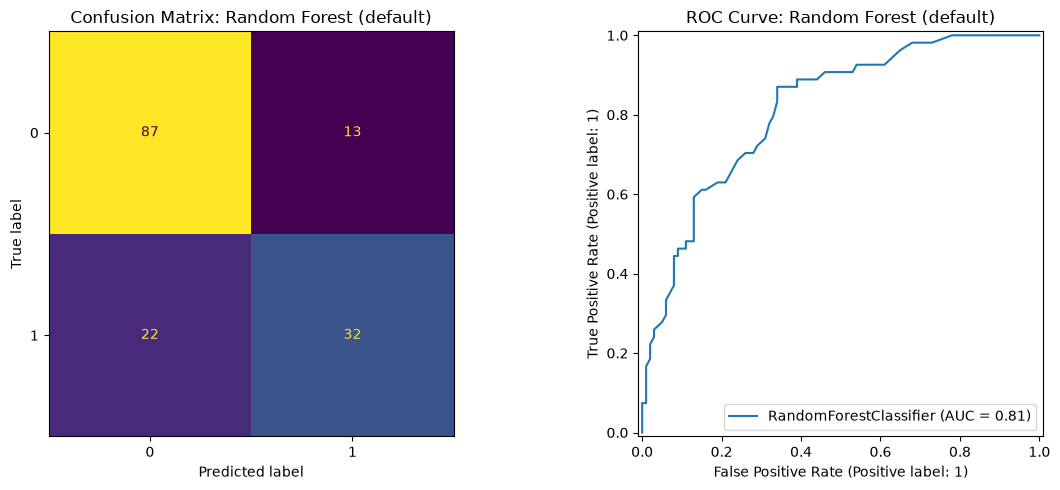

In [10]:
# テストセットのAccuracyが最も高かったモデルを選び、混同行列とROC曲線を表示する。
# 混同行列を見ると、0と1をどのように間違えたかを確認できる。
# ROC曲線を見ると、しきい値を変えたときの分類性能を確認できる。
best_row = comparison_df.sort_values(by='test_accuracy', ascending=False).iloc[0]
best_model_name = best_row['model']
best_model = trained_models[best_model_name]

# kNN は標準化した説明変数を使って学習している。
# Random Forest は標準化していない説明変数を使って学習している。
if best_model_name.startswith('kNN'):
    best_X_test = auto_X_test
else:
    best_X_test = X_test

best_predictions = best_model.predict(best_X_test)

print(f'テストセットのAccuracyが最も高かったモデル: {best_model_name}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title(f'Confusion Matrix: {best_model_name}')

RocCurveDisplay.from_estimator(
    best_model,
    best_X_test,
    y_test,
    ax=axes[1],
)
axes[1].set_title(f'ROC Curve: {best_model_name}')

plt.tight_layout()
plt.show()

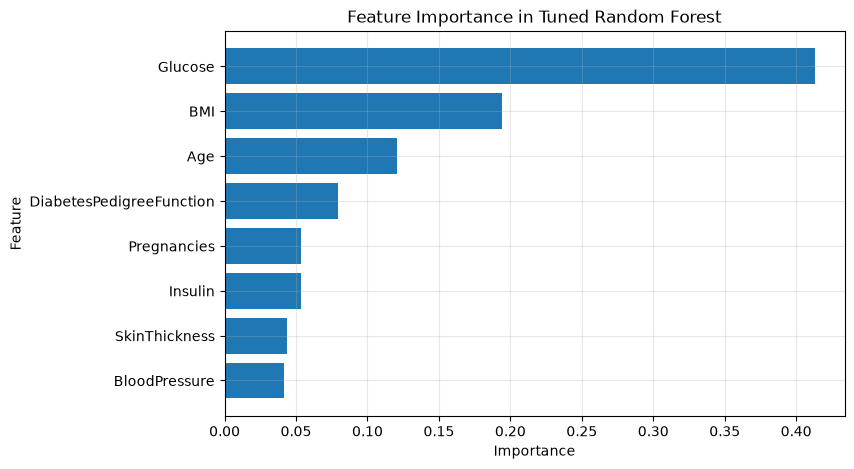

,Feature,Importance
1,Glucose,0.413219
5,BMI,0.194184
7,Age,0.120849
6,DiabetesPedigreeFunction,0.079598
0,Pregnancies,0.053395
4,Insulin,0.053192
3,SkinThickness,0.043983
2,BloodPressure,0.041581


In [11]:
# Random Forest では、どの説明変数が分類に強く使われたかを feature_importances_ で確認できる。
# 値が大きいほど、その特徴量が多くの木の分岐で重要だったと解釈できる。
rf_model_for_importance = trained_models['Random Forest (tuned)']

# GridSearchCV の中に、最適なハイパーパラメータで学習し直したモデルが best_estimator_ として入っている。
rf_best_estimator = rf_model_for_importance.best_estimator_

feature_importance_df = pd.DataFrame(
    {
        'Feature': X_train.columns,
        'Importance': rf_best_estimator.feature_importances_,
    }
).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Tuned Random Forest')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()

feature_importance_df

In [12]:
# 最も良かったモデルについて、テストデータの予測結果の一部を表で確認する。
# actual_Outcome が実際のクラス、predicted_Outcome がモデルの予測クラス。
# probability_Outcome_1 は、Outcome=1 であるとモデルが判断した確率。
best_probabilities = best_model.predict_proba(best_X_test)[:, 1]

prediction_sample = pd.DataFrame(
    {
        'actual_Outcome': y_test,
        'predicted_Outcome': best_predictions,
        'probability_Outcome_1': best_probabilities,
    },
    index=y_test.index,
)

prediction_sample.head(10)

,actual_Outcome,predicted_Outcome,probability_Outcome_1
44,0,1,0.73
672,0,0,0.19
700,0,0,0.05
630,1,0,0.32
81,0,0,0.07
389,0,0,0.43
387,1,0,0.33
408,1,1,0.67
163,0,0,0.03
335,0,1,0.76
